In [8]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
!pip3 install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 9.7 MB/s  0:00:01 eta 0:00:01

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [3]:
from sklearn.datasets import fetch_openml
import numpy as np

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
print("Форма матриці X:", X.shape)
print("Унікальні мітки y:", np.unique(y))

Форма матриці X: (70000, 784)
Унікальні мітки y: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


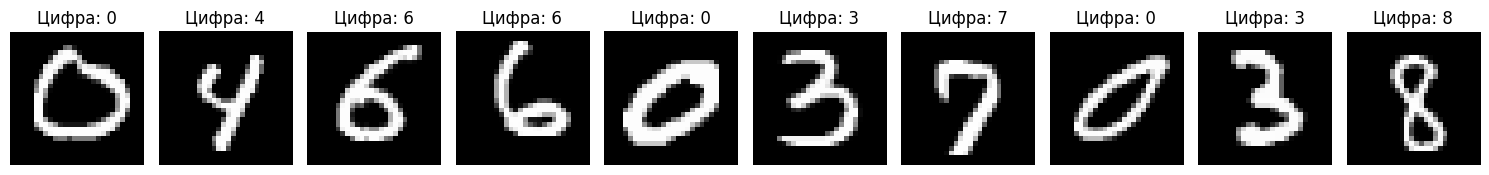

In [9]:
random_indices = np.random.choice(X.shape[0], 10, replace=False)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i, ax in enumerate(axes):
    idx = random_indices[i]
    image = X[idx].reshape(28, 28) 
    ax.imshow(image, cmap='gray') 
    ax.set_title(f"Цифра: {y[idx]}") 
    ax.axis('off') 

plt.tight_layout()
plt.show()

In [13]:
from sklearn.decomposition import PCA

X_norm = X / 255

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_norm)
print(f"Нова форма матриці PCA: {X_pca.shape}")
original = pca.explained_variance_ratio_
print(f"Кількість оригінальності збереглося: {original}")

total_original = sum(original) * 100
print(f"Загальна кількфсть збереження: {total_original:.2f}")

Нова форма матриці PCA: (70000, 3)
Кількість оригінальності збереглося: [0.09746116 0.07155445 0.06149531]
Загальна кількфсть збереження: 23.05


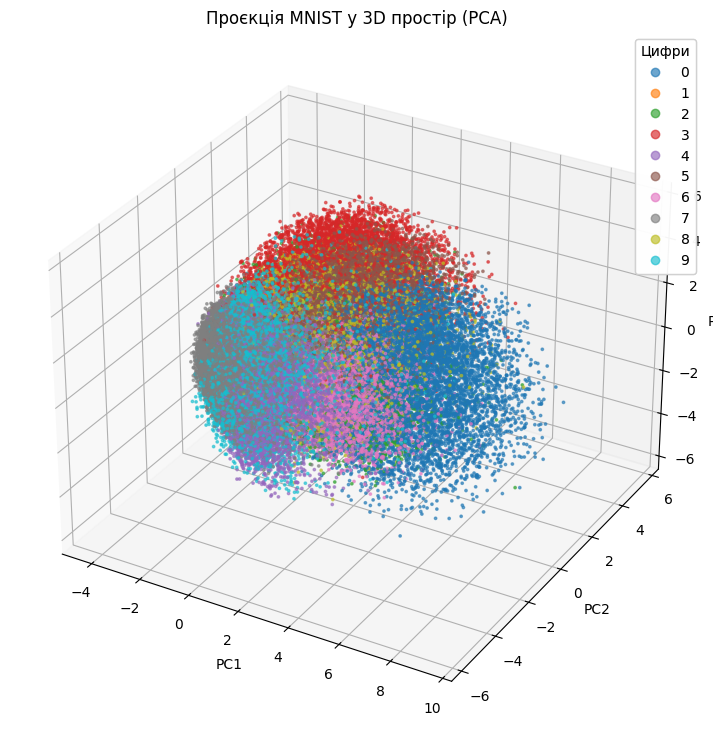

In [14]:
n_samples = 70000
X_subset = X_pca[:n_samples]

y_subset = y[:n_samples].astype(int)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_subset[:, 0],
    X_subset[:, 1], 
    X_subset[:, 2], 
    c=y_subset,     
    cmap='tab10',   
    alpha=0.6,      
    s=3            
)

legend = ax.legend(*scatter.legend_elements(), title="Цифри")
ax.add_artist(legend)

ax.set_title("Проєкція MNIST у 3D простір (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

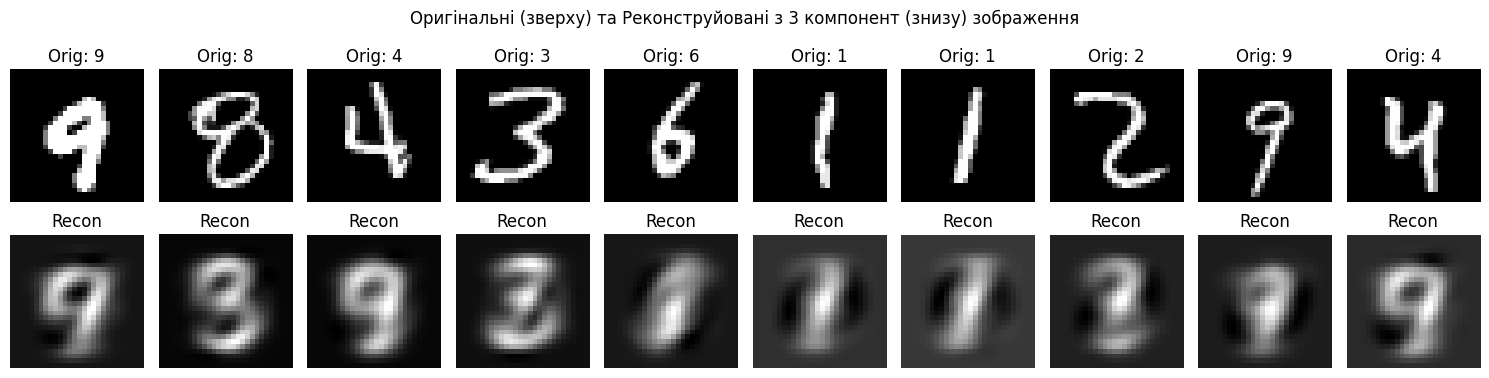

In [ ]:
X_reconstructed = pca.inverse_transform(X_pca)

random_indices = np.random.choice(X_norm.shape[0], 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    idx = random_indices[i]
    
    axes[0, i].imshow(X_norm[idx].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"Orig: {y[idx]}")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(X_reconstructed[idx].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Recon")
    axes[1, i].axis('off')

plt.suptitle('Оригінальні та Реконструйовані з 3 компонент зображення')
plt.tight_layout()
plt.show()

k=  1 | MSE = 0.0607 | Збережена інформація = 9.7%
k=  3 | MSE = 0.0518 | Збережена інформація = 23.1%
k= 10 | MSE = 0.0344 | Збережена інформація = 48.9%
k= 50 | MSE = 0.0117 | Збережена інформація = 82.5%
k=100 | MSE = 0.0057 | Збережена інформація = 91.5%
k=200 | MSE = 0.0023 | Збережена інформація = 96.7%
k=400 | MSE = 0.0003 | Збережена інформація = 99.6%
k=784 | MSE = 0.0000 | Збережена інформація = 100.0%


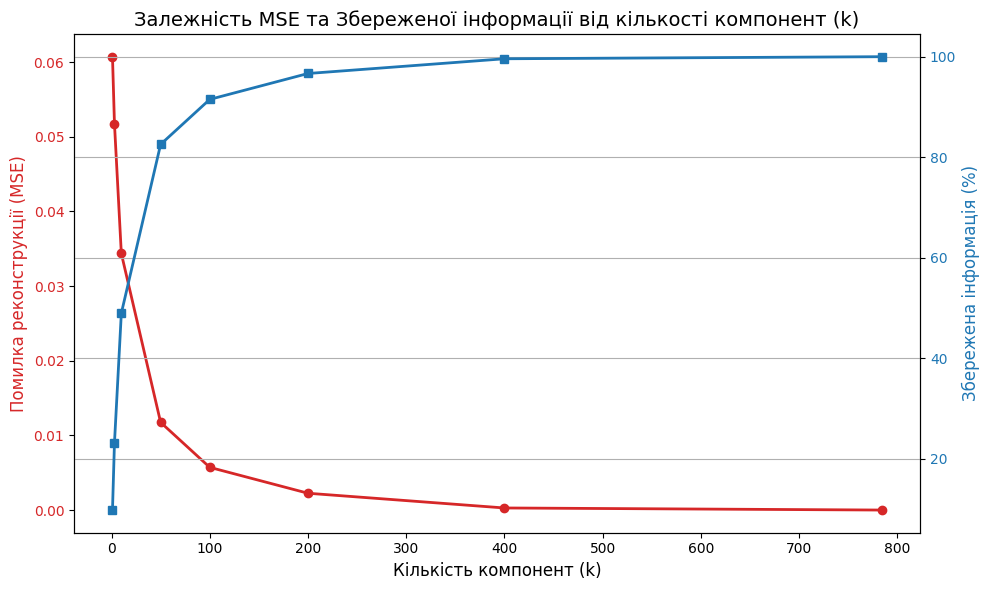

In [16]:
k_values = [1, 3, 10, 50, 100, 200, 400, 784]

mse_scores = []
variance_scores = []

for k in k_values:
    pca_k = PCA(n_components=k)
    X_proj = pca_k.fit_transform(X_norm)
    X_rec = pca_k.inverse_transform(X_proj)
    mse = np.mean((X_norm - X_rec) ** 2)
    mse_scores.append(mse)
    
    variance = np.sum(pca_k.explained_variance_ratio_) * 100
    variance_scores.append(variance)
    
    print(f"k={k:3d} | MSE = {mse:.4f} | Збережена інформація = {variance:.1f}%")

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Кількість компонент (k)', fontsize=12)
ax1.set_ylabel('Помилка реконструкції (MSE)', color='tab:red', fontsize=12)
ax1.plot(k_values, mse_scores, color='tab:red', marker='o', linewidth=2, label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()  
ax2.set_ylabel('Збережена інформація (%)', color='tab:blue', fontsize=12)  
ax2.plot(k_values, variance_scores, color='tab:blue', marker='s', linewidth=2, label='Дисперсія')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title("Залежність MSE та Збереженої інформації від кількості компонент (k)", fontsize=14)
fig.tight_layout()  
plt.grid(True)
plt.show()